In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

train_df = pd.read_csv(
    "CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)


test_df = pd.read_csv(
    "CMAPSSData/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

rul_test_df = pd.read_csv(
    "CMAPSSData/RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

In [3]:
print(train_df.columns.tolist())
print(train_df.shape)
print(train_df.head())
print(test_df.shape)
print(rul_test_df.shape)

['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
(20631, 26)
   unit_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0        1      1       -0.0007       -0.0004         100.0    518.67   
1        1      2        0.0019       -0.0003         100.0    518.67   
2        1      3       -0.0043        0.0003         100.0    518.67   
3        1      4        0.0007        0.0000         100.0    518.67   
4        1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   


In [4]:
max_cycle = train_df.groupby("unit_id")["cycle"].max()
train_df["Remaining Useful Life"] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]

Описание датасета

In [5]:
from IPython.display import display

print("Train dataset overview")
print(f"Rows: {train_df.shape[0]}, columns: {train_df.shape[1]}")
print(f"Units: {train_df['unit_id'].nunique()}")
print(f"Cycle range: {train_df['cycle'].min()} - {train_df['cycle'].max()}")
print(f"Missing values: {train_df.isna().sum().sum()}")

display(train_df.describe().T)

sensor_summary = train_df.filter(like="sensor_").agg(["mean", "std", "min", "max"]).T
display(sensor_summary)

Train dataset overview
Rows: 20631, columns: 27
Units: 100
Cycle range: 1 - 362
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


,mean,std,min,max
sensor_1,518.670000,0.000000e+00,518.6700,518.6700
sensor_2,642.680934,5.000533e-01,641.2100,644.5300
sensor_3,1590.523119,6.131150e+00,1571.0400,1616.9100
sensor_4,1408.933782,9.000605e+00,1382.2500,1441.4900
sensor_5,14.620000,1.776400e-15,14.6200,14.6200
sensor_6,21.609803,1.388985e-03,21.6000,21.6100
sensor_7,553.367711,8.850923e-01,549.8500,556.0600
sensor_8,2388.096652,7.098548e-02,2387.9000,2388.5600
sensor_9,9065.242941,2.208288e+01,9021.7300,9244.5900
sensor_10,1.300000,0.000000e+00,1.3000,1.3000


 тестики

In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
target_col = "Remaining Useful Life"

feature_cols = [
    col for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

test_last_rows = (
    test_df
    .sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_last_rows[feature_cols]
y_test = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test) != len(y_test):
    raise ValueError("test feature rows must match RUL target rows")

rf_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf":3,
    "min_samples_split":5,
    "random_state": 42,
    "n_jobs": -1,
}


print(f"Train units: {train_df['unit_id'].nunique()}, rows: {len(X_train)}")
print(f"Test units: {test_last_rows['unit_id'].nunique()}, rows: {len(X_test)}")

Train units: 100, rows: 20631
Test units: 100, rows: 100


In [8]:
rf_model = RandomForestRegressor(**rf_params)
rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


Самый важный признак: sensor_11 (importance=0.459627)

Топ-10 признаков по важности:


,feature,importance
0,sensor_11,0.459627
1,sensor_9,0.128949
2,sensor_4,0.099566
3,sensor_12,0.043860
4,sensor_7,0.034325
5,sensor_14,0.034282
6,sensor_15,0.029590
7,sensor_21,0.028020
8,sensor_3,0.024589
9,sensor_2,0.023622


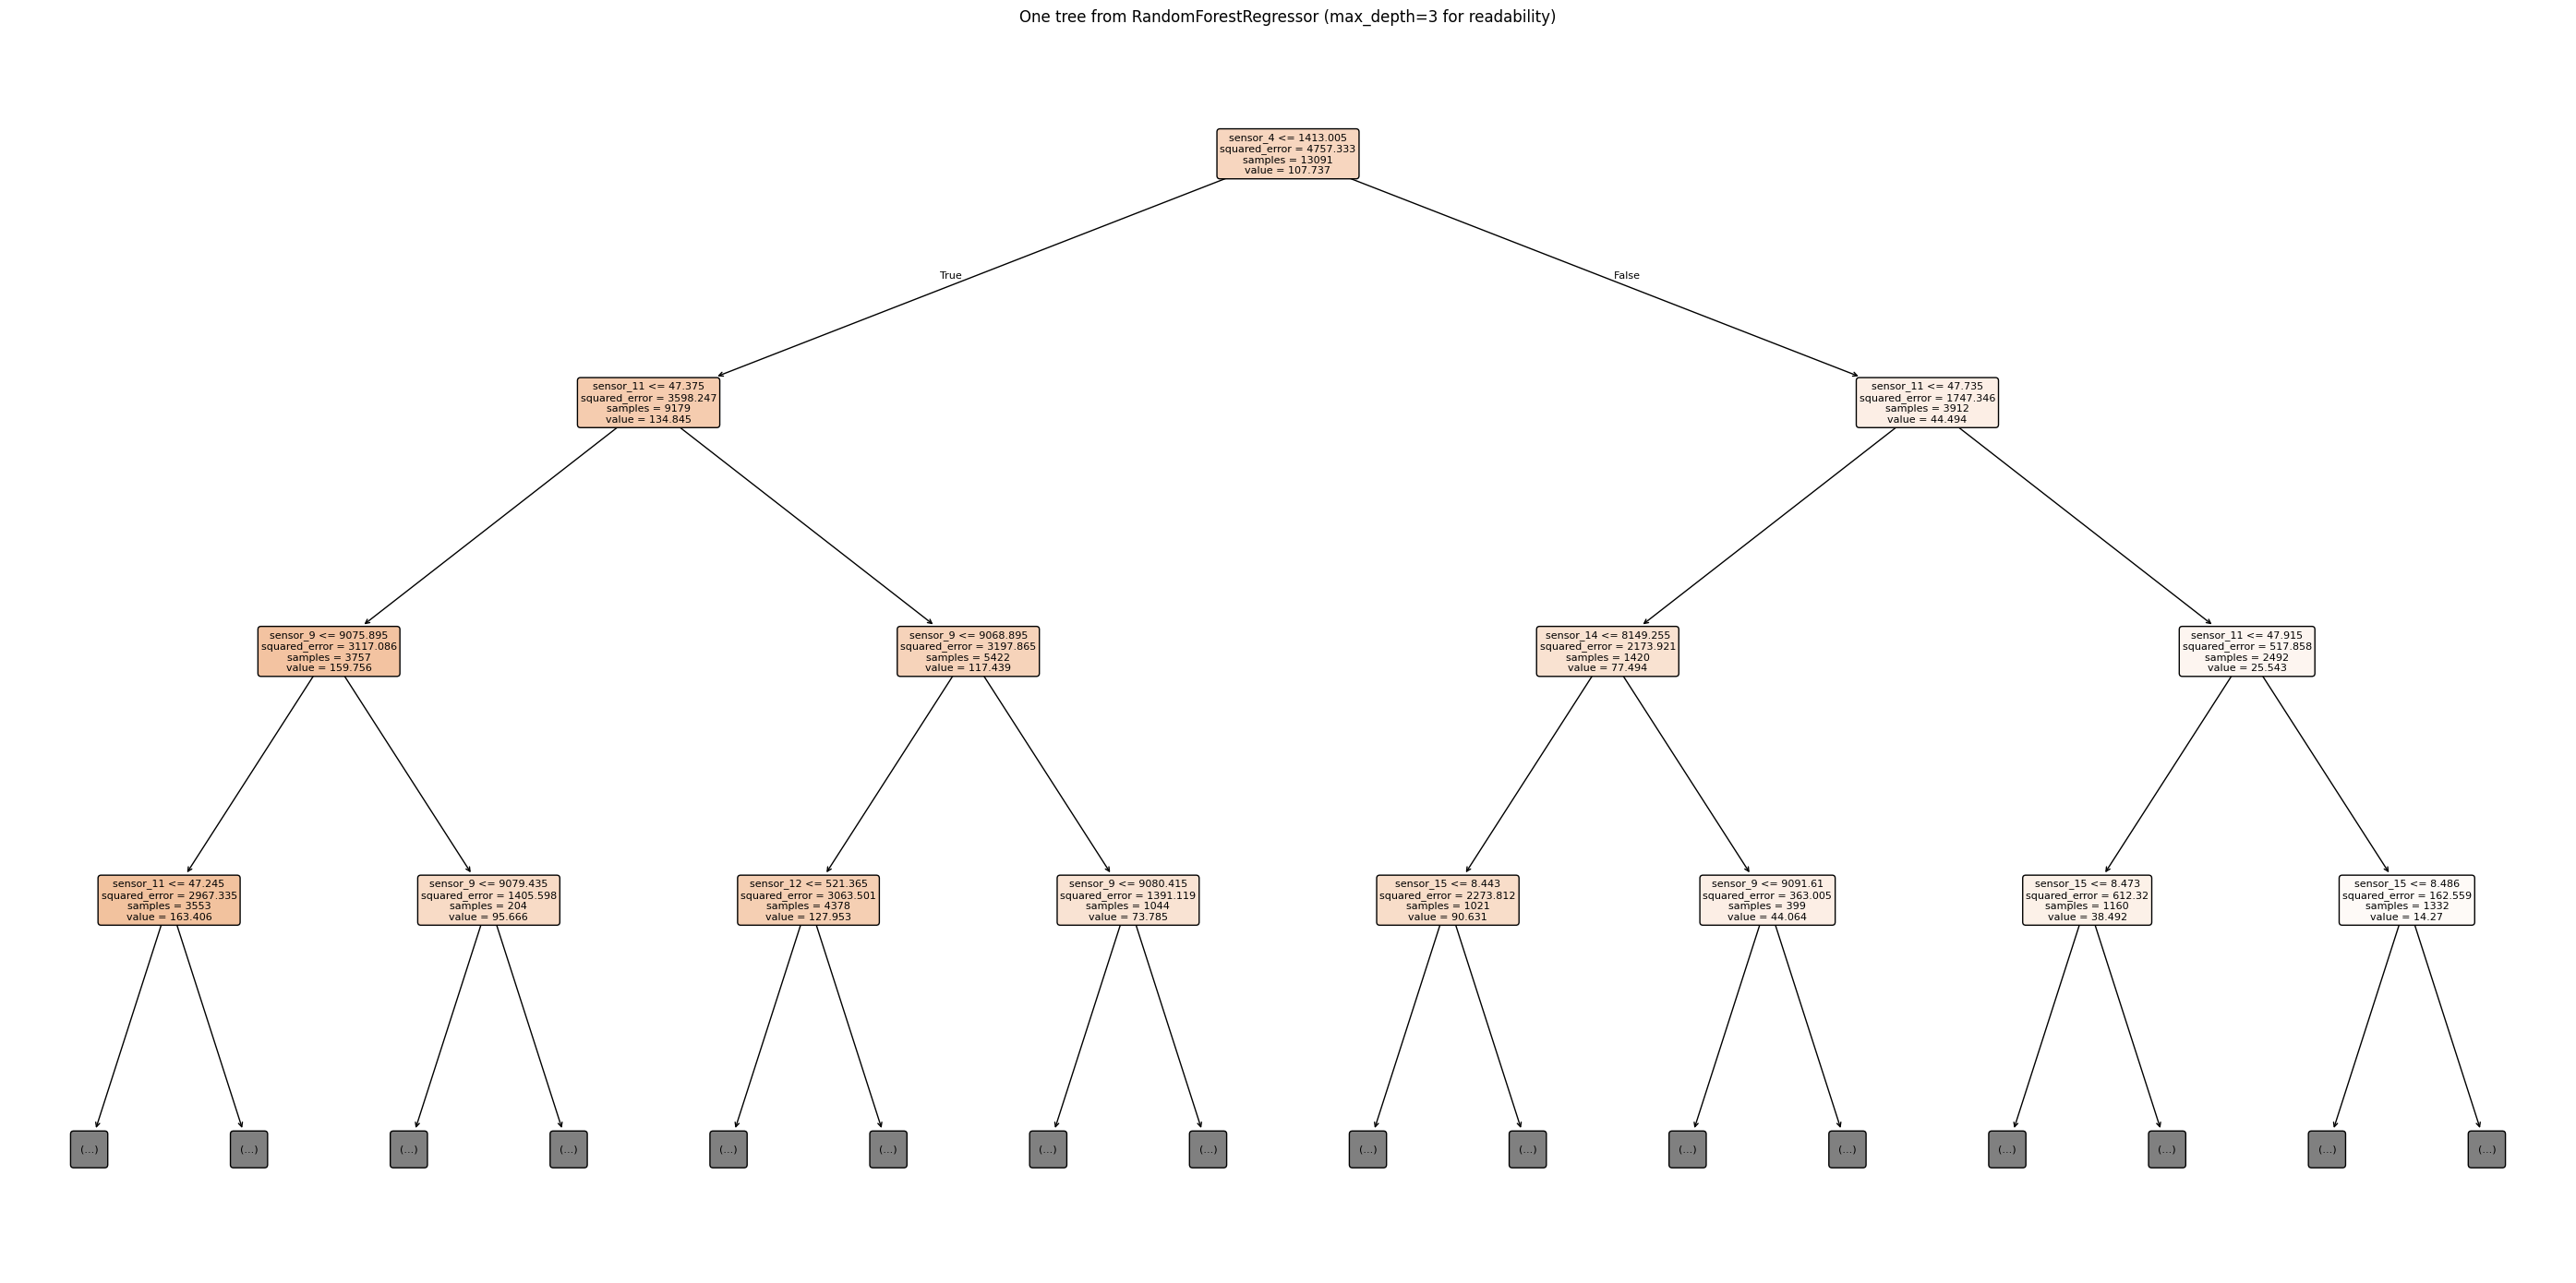

Изображение дерева сохранится в файл: rf_tree_example.png


In [20]:
# Важность признаков для первой модели Random Forest
feature_importance_df = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

most_important_feature = feature_importance_df.loc[0]
print(
    "Самый важный признак:",
    f"{most_important_feature['feature']} (importance={most_important_feature['importance']:.6f})"
)

print("\nТоп-10 признаков по важности:")
display(feature_importance_df.head(10))

# Визуализация одного дерева из ансамбля
from sklearn.tree import plot_tree

single_tree = rf_model.estimators_[0]

plt.figure(figsize=(28, 14))
plot_tree(
    single_tree,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("One tree from RandomForestRegressor (max_depth=3 for readability)")
plt.tight_layout()
plt.savefig("rf_tree_example.png", dpi=200, bbox_inches="tight")
plt.show()

print("Изображение дерева сохранится в файл: rf_tree_example.png")

In [9]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae, rmse, r2],
    }
)

metrics_df

,metric,value
0,MAE,24.146704
1,RMSE,32.706555
2,R2,0.380545


In [10]:
print(train_df["Remaining Useful Life"].describe())


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mean_rul = y_train.mean()
y_pred_dummy = np.full(len(y_test), mean_rul)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = mean_squared_error(y_test, y_pred_dummy) ** 0.5

print("Dummy MAE =", mae_dummy)
print("Dummy RMSE =", rmse_dummy)
#Понять насколько ошибка 24 это много

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: Remaining Useful Life, dtype: float64
Dummy MAE = 40.87930202123019
Dummy RMSE = 52.62485752612688


На данный момент была проблема что он смотрел только на последнюю но ведь мы смотрим в целом на картину по последним изменениям поэтому добавим окно

In [50]:
window_size = 30

# Ручная настройка исключений сенсоров:
# - по номеру: [1, 5, 14]
# - по имени: ["sensor_1", "sensor_5"]
excluded_sensors_by_number = [19, 9, 3, 1, 5, 10, 7]
excluded_sensors_by_name = []

excluded_sensor_cols = {
    f"sensor_{int(sensor_num)}" for sensor_num in excluded_sensors_by_number
}
for sensor_name in excluded_sensors_by_name:
    sensor_name = str(sensor_name).strip()
    if sensor_name.startswith("sensor_"):
        excluded_sensor_cols.add(sensor_name)
    elif sensor_name.isdigit():
        excluded_sensor_cols.add(f"sensor_{int(sensor_name)}")

excluded_sensor_cols = sorted(col for col in excluded_sensor_cols if col in feature_cols)
window_base_feature_cols = [col for col in feature_cols if col not in excluded_sensor_cols]

if not window_base_feature_cols:
    raise ValueError("No features left for training after sensor exclusions")


def build_lag_window_features(source_df, selected_feature_cols, include_target=False, require_full_window=False):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    first_values = sorted_df.groupby("unit_id")[selected_feature_cols].transform("first")
    lagged_parts = []

    for lag in range(window_size):
        shifted = sorted_df.groupby("unit_id")[selected_feature_cols].shift(lag)
        if not require_full_window:
            shifted = shifted.fillna(first_values)
        suffix = "t" if lag == 0 else f"t_minus_{lag}"
        shifted.columns = [f"{col}_{suffix}" for col in selected_feature_cols]
        lagged_parts.append(shifted)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *lagged_parts],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= window_size].dropna()

    return result_df.reset_index(drop=True)

window_train_df = build_lag_window_features(
    train_df,
    selected_feature_cols=window_base_feature_cols,
    include_target=True,
    require_full_window=True,
)
window_test_df = build_lag_window_features(
    test_df,
    selected_feature_cols=window_base_feature_cols,
    include_target=False,
    require_full_window=False,
)

window_feature_cols = [
    col for col in window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

window_test_last_rows = (
    window_test_df
    .sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_window = window_train_df[window_feature_cols]
y_train_window = window_train_df[target_col]

X_test_window = window_test_last_rows[window_feature_cols]
y_test_window = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test_window) != len(y_test_window):
    raise ValueError("test feature rows must match RUL target rows")

window_rf_params = rf_params.copy()

print(f"Window size: {window_size}")
print("Train mode: require full window; test mode: use available history and keep every test unit")
print(f"Excluded sensors: {excluded_sensor_cols if excluded_sensor_cols else 'none'}")
print(f"Base features used: {len(window_base_feature_cols)} / {len(feature_cols)}")
print(f"Train rows: {len(X_train_window)}, features: {X_train_window.shape[1]}")
print(f"Test rows: {len(X_test_window)}, features: {X_test_window.shape[1]}")

Window size: 30
Train mode: require full window; test mode: use available history and keep every test unit
Excluded sensors: ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_3', 'sensor_5', 'sensor_7', 'sensor_9']
Base features used: 17 / 24
Train rows: 17731, features: 510
Test rows: 100, features: 510


In [51]:
import time
window_rf_model = RandomForestRegressor(**window_rf_params)
window_train_start = time.perf_counter()
window_rf_model.fit(X_train_window, y_train_window)
window_train_seconds = time.perf_counter() - window_train_start
print("Window Random Forest model trained")
print(f"Window Random Forest model trained in {window_train_seconds:.2f} sec")

Window Random Forest model trained
Window Random Forest model trained in 121.23 sec


In [52]:
# Диагностика качества оконной модели: метрики, важность признаков и near-failure анализ
import numpy as np

y_pred_window = window_rf_model.predict(X_test_window)
window_error = y_pred_window - y_test_window
window_abs_error = np.abs(window_error)

mae_window = mean_absolute_error(y_test_window, y_pred_window)
rmse_window = mean_squared_error(y_test_window, y_pred_window) ** 0.5
r2_window = r2_score(y_test_window, y_pred_window)

mean_error_window = float(window_error.mean())
median_abs_error_window = float(np.median(window_abs_error))
max_abs_error_window = float(window_abs_error.max())

# Near-failure: объекты с истинным RUL <= window_size
near_failure_mask = y_test_window <= window_size
near_failure_share = float(near_failure_mask.mean())
if near_failure_mask.any():
    near_failure_mae = mean_absolute_error(
        y_test_window[near_failure_mask],
        y_pred_window[near_failure_mask],
    )
else:
    near_failure_mae = np.nan

# Ключевой показатель важности
window_feature_importance_df = (
    pd.DataFrame(
        {
            "feature": window_feature_cols,
            "importance": window_rf_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

most_important_window_feature = window_feature_importance_df.loc[0]

# Агрегированная важность по базовым сенсорам/настройкам (без лагов)
window_feature_importance_df["base_feature"] = window_feature_importance_df["feature"].str.replace(
    r"_(t|t_minus_\\d+)$", "", regex=True
)
window_base_importance_df = (
    window_feature_importance_df
    .groupby("base_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

most_important_base_feature = window_base_importance_df.loc[0]

window_metrics_df = pd.DataFrame(
    {
        "metric": [
            "MAE",
            "RMSE",
            "R2",
            "Train time (sec)",
            "Window size",
            "Mean error (bias)",
            "Median absolute error",
            "Max absolute error",
            "Near-failure share (RUL <= window)",
            "Near-failure MAE",
        ],
        "value": [
            mae_window,
            rmse_window,
            r2_window,
            window_train_seconds,
            window_size,
            mean_error_window,
            median_abs_error_window,
            max_abs_error_window,
            near_failure_share,
            near_failure_mae,
        ],
    }
)

print(f"Window size: {window_size}")
print(f"Training time: {window_train_seconds:.2f} sec")
print(f"Excluded sensors: {excluded_sensor_cols if excluded_sensor_cols else 'none'}")
print(
    "Most important lag feature:",
    f"{most_important_window_feature['feature']} (importance={most_important_window_feature['importance']:.6f})"
)
print(
    "Most important base feature:",
    f"{most_important_base_feature['base_feature']} (importance_sum={most_important_base_feature['importance']:.6f})"
)
window_feature_importance_df.insert(0, "rank", range(1, len(window_feature_importance_df) + 1))
window_base_importance_df.insert(0, "rank", range(1, len(window_base_importance_df) + 1))

print("\nTop-10 lag features by importance:")
display(window_feature_importance_df.head(10))
print("\nAll lag features by importance:")
display(window_feature_importance_df)

print("\nTop-10 base features by summed importance:")
display(window_base_importance_df.head(10))
print("\nAll base sensors/features by summed importance:")
display(window_base_importance_df)

print("\nWindow model metrics:")
display(window_metrics_df)

Window size: 30
Training time: 121.23 sec
Excluded sensors: ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_3', 'sensor_5', 'sensor_7', 'sensor_9']
Most important lag feature: sensor_11_t (importance=0.391715)
Most important base feature: sensor_11 (importance_sum=0.391715)

Top-10 lag features by importance:


,rank,feature,importance,base_feature
0,1,sensor_11_t,0.391715,sensor_11
1,2,sensor_11_t_minus_1,0.105175,sensor_11_t_minus_1
2,3,sensor_14_t,0.041900,sensor_14
3,4,sensor_11_t_minus_2,0.019656,sensor_11_t_minus_2
4,5,sensor_12_t,0.013380,sensor_12
5,6,sensor_14_t_minus_1,0.013360,sensor_14_t_minus_1
6,7,sensor_4_t,0.011355,sensor_4
7,8,sensor_14_t_minus_3,0.007567,sensor_14_t_minus_3
8,9,sensor_11_t_minus_3,0.007556,sensor_11_t_minus_3
9,10,sensor_12_t_minus_1,0.007079,sensor_12_t_minus_1



All lag features by importance:


,rank,feature,importance,base_feature
0,1,sensor_11_t,0.391715,sensor_11
1,2,sensor_11_t_minus_1,0.105175,sensor_11_t_minus_1
2,3,sensor_14_t,0.041900,sensor_14
3,4,sensor_11_t_minus_2,0.019656,sensor_11_t_minus_2
4,5,sensor_12_t,0.013380,sensor_12
...,...,...,...,...
505,506,sensor_18_t_minus_26,0.000000,sensor_18_t_minus_26
506,507,sensor_16_t_minus_29,0.000000,sensor_16_t_minus_29
507,508,op_setting_3_t,0.000000,op_setting_3
508,509,sensor_18_t_minus_29,0.000000,sensor_18_t_minus_29



Top-10 base features by summed importance:


,rank,base_feature,importance
0,1,sensor_11,0.391715
1,2,sensor_11_t_minus_1,0.105175
2,3,sensor_14,0.041900
3,4,sensor_11_t_minus_2,0.019656
4,5,sensor_12,0.013380
5,6,sensor_14_t_minus_1,0.013360
6,7,sensor_4,0.011355
7,8,sensor_14_t_minus_3,0.007567
8,9,sensor_11_t_minus_3,0.007556
9,10,sensor_12_t_minus_1,0.007079



All base sensors/features by summed importance:


,rank,base_feature,importance
0,1,sensor_11,0.391715
1,2,sensor_11_t_minus_1,0.105175
2,3,sensor_14,0.041900
3,4,sensor_11_t_minus_2,0.019656
4,5,sensor_12,0.013380
...,...,...,...
505,506,op_setting_3_t_minus_28,0.000000
506,507,op_setting_3_t_minus_29,0.000000
507,508,op_setting_3_t_minus_3,0.000000
508,509,op_setting_3_t_minus_4,0.000000



Window model metrics:


,metric,value
0,MAE,19.485816
1,RMSE,25.700028
2,R2,0.617521
3,Train time (sec),121.234339
4,Window size,30.000000
5,Mean error (bias),15.603826
6,Median absolute error,17.070803
7,Max absolute error,69.920666
8,Near-failure share (RUL <= window),0.250000
9,Near-failure MAE,10.100573


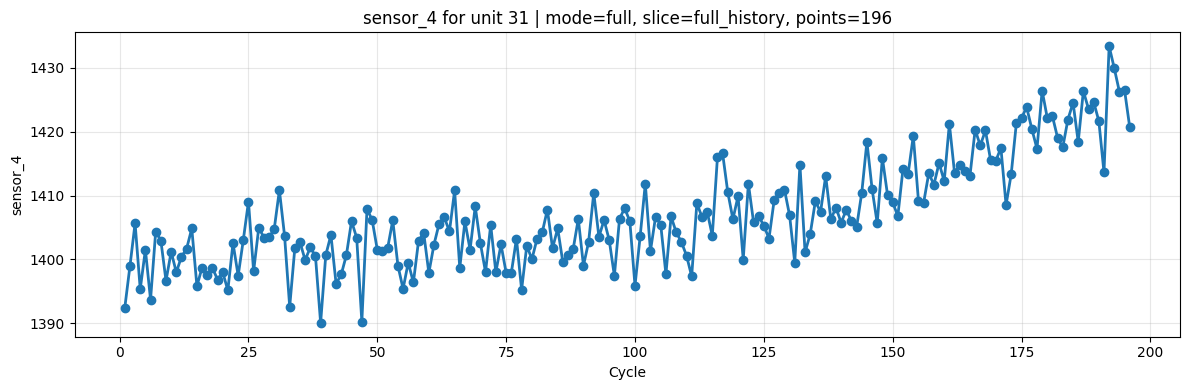

Plotted sensor=sensor_4, unit_id=31, display_mode=full, window_position=middle, plot_window_size=100, points=196


In [44]:
# Универсальный просмотр графика сенсора: выбор режима, сенсора, unit и позиции окна
# display_mode:
# - "window": отрезок длины plot_window_size
# - "full": вся история выбранного unit
# window_position_for_plot работает для режима "window": "start" | "middle" | "end"

display_mode = "full"              # "window" | "full"
selected_sensor_for_plot = "sensor_4"   # example: "sensor_12"
selected_unit_id_for_plot = 31           # example: 7; if None -> first available
window_position_for_plot = "middle"     # "start" | "middle" | "end"
plot_window_size = window_size           # можно задать отдельно, например 30

if selected_sensor_for_plot not in columns:
    raise ValueError(f"Unknown sensor: {selected_sensor_for_plot}")

if display_mode not in {"window", "full"}:
    raise ValueError("display_mode must be one of: 'window', 'full'")

if plot_window_size <= 0:
    raise ValueError("plot_window_size must be > 0")

if window_position_for_plot not in {"start", "middle", "end"}:
    raise ValueError("window_position_for_plot must be one of: 'start', 'middle', 'end'")

available_units = sorted(test_df["unit_id"].unique())
if selected_unit_id_for_plot is None:
    selected_unit_id_for_plot = int(available_units[0])

if selected_unit_id_for_plot not in available_units:
    raise ValueError(f"unit_id={selected_unit_id_for_plot} is not present in test_df")

unit_history_df = (
    test_df[test_df["unit_id"] == selected_unit_id_for_plot]
    .sort_values("cycle")
    .reset_index(drop=True)
)

history_len = len(unit_history_df)
if history_len == 0:
    raise ValueError("Selected unit has no history")

if display_mode == "full":
    plot_window_df = unit_history_df.copy()
    selected_slice_label = "full_history"
else:
    if history_len <= plot_window_size:
        plot_window_df = unit_history_df.copy()
        selected_slice_label = "full_history_short"
    else:
        if window_position_for_plot == "start":
            plot_window_df = unit_history_df.head(plot_window_size).copy()
        elif window_position_for_plot == "end":
            plot_window_df = unit_history_df.tail(plot_window_size).copy()
        else:
            start_idx = max((history_len - plot_window_size) // 2, 0)
            end_idx = start_idx + plot_window_size
            plot_window_df = unit_history_df.iloc[start_idx:end_idx].copy()

        selected_slice_label = f"window_{window_position_for_plot}"

plt.figure(figsize=(12, 4))
plt.plot(
    plot_window_df["cycle"],
    plot_window_df[selected_sensor_for_plot],
    marker="o",
    linewidth=2,
)
plt.title(
    f"{selected_sensor_for_plot} for unit {selected_unit_id_for_plot} | "
    f"mode={display_mode}, slice={selected_slice_label}, points={len(plot_window_df)}"
)
plt.xlabel("Cycle")
plt.ylabel(selected_sensor_for_plot)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Plotted sensor={selected_sensor_for_plot}, unit_id={selected_unit_id_for_plot}, "
    f"display_mode={display_mode}, window_position={window_position_for_plot}, "
    f"plot_window_size={plot_window_size}, points={len(plot_window_df)}"
)

На данных в большом количестве тяжело учить плюс это перегружает дерево поэтому вместо этого делаем сбалансированные признаки

In [14]:
agg_window_size = 50

if agg_window_size < 2:
    raise ValueError("agg_window_size must be at least 2")

def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x ** 2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator

def build_agg_window_features(source_df, include_target=False, require_full_window=False):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = agg_window_size if require_full_window else 1
    rolling_features = sorted_df.groupby("unit_id")[feature_cols].rolling(
        window=agg_window_size,
        min_periods=min_periods,
    )

    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)

    range_features = max_features - min_features
    window_start_values = sorted_df.groupby("unit_id")[feature_cols].shift(agg_window_size - 1)
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[feature_cols].transform("first")
        window_start_values = window_start_values.fillna(first_available_values)
    delta_features = sorted_df[feature_cols] - window_start_values
    last_minus_mean_features = sorted_df[feature_cols] - mean_features
    slope_features = rolling_features.apply(
        calculate_slope,
        raw=True,
    ).reset_index(level=0, drop=True)

    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
    }

    agg_feature_parts = []

    for suffix, block in feature_blocks.items():
        renamed_block = block.copy()
        renamed_block.columns = [
            f"{col}_{suffix}_{agg_window_size}"
            for col in renamed_block.columns
        ]
        agg_feature_parts.append(renamed_block)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *agg_feature_parts],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= agg_window_size].dropna()

    return result_df.reset_index(drop=True)

agg_window_train_df = build_agg_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
agg_window_test_df = build_agg_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

agg_window_feature_cols = [
    col for col in agg_window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

agg_window_test_last_rows = (
    agg_window_test_df
    .sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_agg_window = agg_window_train_df[agg_window_feature_cols]
y_train_agg_window = agg_window_train_df[target_col]

X_test_agg_window = agg_window_test_last_rows[agg_window_feature_cols]
y_test_agg_window = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test_agg_window) != len(y_test_agg_window):
    raise ValueError("test feature rows must match RUL target rows")

agg_window_rf_params = rf_params.copy()

print(f"Aggregated window size: {agg_window_size}")
print("Train mode: require full window; test mode: use available history and keep every test unit")
print(f"Train rows: {len(X_train_agg_window)}, features: {X_train_agg_window.shape[1]}")
print(f"Test rows: {len(X_test_agg_window)}, features: {X_test_agg_window.shape[1]}")

Aggregated window size: 50
Train mode: require full window; test mode: use available history and keep every test unit
Train rows: 15731, features: 192
Test rows: 100, features: 192


In [15]:
agg_window_rf_model = RandomForestRegressor(**agg_window_rf_params)
agg_window_rf_model.fit(X_train_agg_window, y_train_agg_window)

print("Aggregated window Random Forest model trained")

Aggregated window Random Forest model trained


In [16]:
y_pred_agg_window = agg_window_rf_model.predict(X_test_agg_window)

mae_agg_window = mean_absolute_error(y_test_agg_window, y_pred_agg_window)
rmse_agg_window = mean_squared_error(y_test_agg_window, y_pred_agg_window) ** 0.5
r2_agg_window = r2_score(y_test_agg_window, y_pred_agg_window)

agg_window_metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae_agg_window, rmse_agg_window, r2_agg_window],
    }
)

agg_window_metrics_df

,metric,value
0,MAE,13.912540
1,RMSE,22.101208
2,R2,0.717139


еще больше критериев А также окно теперь не обрубает а если меньше то берет все

In [17]:
extended_agg_window_size = 50
selected_extra_features = ["median", "iqr"]

if extended_agg_window_size < 2:
    raise ValueError("extended_agg_window_size must be at least 2")

def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x ** 2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator

def build_extended_agg_window_features(source_df, include_target=False, require_full_window=False):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = extended_agg_window_size if require_full_window else 1
    rolling_features = sorted_df.groupby("unit_id")[feature_cols].rolling(
        window=extended_agg_window_size,
        min_periods=min_periods,
    )

    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)
    median_features = rolling_features.median().reset_index(level=0, drop=True)
    q25_features = rolling_features.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling_features.quantile(0.75).reset_index(level=0, drop=True)

    range_features = max_features - min_features
    iqr_features = q75_features - q25_features
    window_start_values = sorted_df.groupby("unit_id")[feature_cols].shift(extended_agg_window_size - 1)
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[feature_cols].transform("first")
        window_start_values = window_start_values.fillna(first_available_values)
    delta_features = sorted_df[feature_cols] - window_start_values
    last_minus_mean_features = sorted_df[feature_cols] - mean_features
    slope_features = rolling_features.apply(
        calculate_slope,
        raw=True,
    ).reset_index(level=0, drop=True)

    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": iqr_features,
    }

    agg_feature_parts = []

    for suffix, block in feature_blocks.items():
        renamed_block = block.copy()
        renamed_block.columns = [
            f"{col}_{suffix}_{extended_agg_window_size}"
            for col in renamed_block.columns
        ]
        agg_feature_parts.append(renamed_block)

    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)

    result_df = pd.concat(
        [sorted_df[metadata_cols], *agg_feature_parts],
        axis=1,
    )

    if require_full_window:
        result_df = result_df[result_df["cycle"] >= extended_agg_window_size].dropna()

    return result_df.reset_index(drop=True)

extended_agg_window_train_df = build_extended_agg_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
extended_agg_window_test_df = build_extended_agg_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

extended_agg_window_feature_cols = [
    col for col in extended_agg_window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]

extended_agg_window_test_last_rows = (
    extended_agg_window_test_df
    .sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_extended_agg_window = extended_agg_window_train_df[extended_agg_window_feature_cols]
y_train_extended_agg_window = extended_agg_window_train_df[target_col]

X_test_extended_agg_window = extended_agg_window_test_last_rows[extended_agg_window_feature_cols]
y_test_extended_agg_window = rul_test_df["RUL"].reset_index(drop=True)

if len(X_test_extended_agg_window) != len(y_test_extended_agg_window):
    raise ValueError("test feature rows must match RUL target rows")

extended_agg_window_rf_params = rf_params.copy()

print(f"Extended aggregated window size: {extended_agg_window_size}")
print("Train mode: require full window; test mode: use available history and keep every test unit")
print(f"Selected extra features: {selected_extra_features}")
print(f"Train rows: {len(X_train_extended_agg_window)}, features: {X_train_extended_agg_window.shape[1]}")
print(f"Test rows: {len(X_test_extended_agg_window)}, features: {X_test_extended_agg_window.shape[1]}")

Extended aggregated window size: 50
Train mode: require full window; test mode: use available history and keep every test unit
Selected extra features: ['median', 'iqr']
Train rows: 15731, features: 240
Test rows: 100, features: 240


In [18]:
extended_agg_window_rf_model = RandomForestRegressor(**extended_agg_window_rf_params)
extended_agg_window_rf_model.fit(X_train_extended_agg_window, y_train_extended_agg_window)

print("Extended aggregated window Random Forest model trained")

Extended aggregated window Random Forest model trained


In [19]:
y_pred_extended_agg_window = extended_agg_window_rf_model.predict(X_test_extended_agg_window)

mae_extended_agg_window = mean_absolute_error(y_test_extended_agg_window, y_pred_extended_agg_window)
rmse_extended_agg_window = mean_squared_error(y_test_extended_agg_window, y_pred_extended_agg_window) ** 0.5
r2_extended_agg_window = r2_score(y_test_extended_agg_window, y_pred_extended_agg_window)

extended_agg_window_metrics_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae_extended_agg_window, rmse_extended_agg_window, r2_extended_agg_window],
    }
)

extended_agg_window_metrics_df

,metric,value
0,MAE,13.707230
1,RMSE,20.694839
2,R2,0.751993
